# Colab Training Launcher

Run AntiBERTy or ESM-2 contrastive fine-tuning on Google Colab. This notebook intentionally keeps model and training logic in `src/`; it only mounts persistent storage, prepares the repo, launches training, resumes checkpoints, evaluates the best checkpoint, and plots metrics.

Checkpoints are written to Google Drive via `--output_dir`, so interrupted Colab sessions can resume from `checkpoint_latest.pt`.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

# Keep this on persistent storage. Adjust the path if you prefer a different Drive folder.
DRIVE_OUTPUT = "/content/drive/MyDrive/6.8711_Project/checkpoints"

Mounted at /content/drive


In [10]:
import os

REPO_URL = "https://github.com/sgabriel17/contrastive_learning_for_antibody-epitope_reimplementation.git"
REPO_DIR = "/content/contrastive_learning_for_antibody-epitope_reimplementation"
BRANCH   = "main"  # Change to your working branch if needed.

os.environ["REPO_URL"] = REPO_URL
os.environ["REPO_DIR"] = REPO_DIR
os.environ["BRANCH"]   = BRANCH

print("REPO_URL =", REPO_URL)
print("REPO_DIR =", REPO_DIR)
print("BRANCH   =", BRANCH)

REPO_URL = https://github.com/sgabriel17/contrastive_learning_for_antibody-epitope_reimplementation.git
REPO_DIR = /content/contrastive_learning_for_antibody-epitope_reimplementation
BRANCH   = main


In [11]:
%%bash
set -euo pipefail
# If the kernel's cwd pointed inside REPO_DIR, `rm -rf` deletes its parent chain and bash/git
# can no longer read cwd (shell-init/getcwd errors). Anchor in /content before doing anything else.
mkdir -p /content
cd /content

rm -rf "$REPO_DIR"
# Shallow clone the target branch directly (same as default branch mismatches shallow clone).
GIT_TERMINAL_PROMPT=0 git clone --depth 1 --branch "$BRANCH" "$REPO_URL" "$REPO_DIR"
cd "$REPO_DIR"

echo "Ready: $(git rev-parse --short HEAD) on branch $(git branch --show-current)"

Ready: 493c79b on branch main


Cloning into '/content/contrastive_learning_for_antibody-epitope_reimplementation'...


In [12]:
# Move the kernel cwd into the repo for all subsequent cells.
# If cwd was deleted (e.g. re-clone deleted the repo while the kernel pointed inside it),
# getcwd()/git can fail until we anchor under /content.
import os
from IPython import get_ipython

try:
    os.getcwd()
except (FileNotFoundError, OSError):
    os.makedirs("/content", exist_ok=True)
    os.chdir("/content")

get_ipython().run_line_magic('cd', os.environ['REPO_DIR'])
print('cwd =', os.getcwd())


/content/contrastive_learning_for_antibody-epitope_reimplementation
cwd = /content/contrastive_learning_for_antibody-epitope_reimplementation


In [13]:
# Colab provides Linux/CUDA, so bitsandbytes installs normally here.
!pip install -q -r requirements.txt

import torch
import transformers
import peft

print("torch       ", torch.__version__)
print("transformers", transformers.__version__)
print("peft        ", peft.__version__)
print("cuda        ", torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 MB 20.9 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.2 MB/s eta 0:00:00:00:01
torch        2.10.0+cpu
transformers 5.0.0
peft         0.19.1
cuda         False


In [14]:
import pandas as pd
import torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
if torch.cuda.is_available():
    free_bytes, total_bytes = torch.cuda.mem_get_info()
    print(f"GPU memory: {free_bytes / 1e9:.1f} GB free / {total_bytes / 1e9:.1f} GB total")

df = pd.read_pickle("ablang_model/train/rbd_dataset.pd")
print("Dataset shape:", df.shape)
print("DATASET counts:")
print(df["DATASET"].value_counts())
main_epitopes = ["A", "B", "C", "D1", "D2", "E1", "E2.1", "E2.2", "E3", "F1", "F2", "F3"]
print("12-bin uppercase split counts:")
print(df[df["DATASET"].isin(["TRAIN", "VAL", "TEST"]) & df["EPITOPE"].isin(main_epitopes)]["DATASET"].value_counts())

GPU: none
Dataset shape: (3143, 25)
DATASET counts:
DATASET
TRAIN    2465
TEST      307
VAL       269
train      71
test       31
Name: count, dtype: int64
12-bin uppercase split counts:
DATASET
TRAIN    2465
TEST      307
VAL       269
Name: count, dtype: int64


In [15]:
# ── Edit these per experiment ──────────────────────────────────────────────────
ENCODER = "antiberty"   # "antiberty" or "esm2"
RUN_NAME = f"{ENCODER}_run1"
OUTPUT_DIR = f"{DRIVE_OUTPUT}/{RUN_NAME}"

EPOCHS = 400
LR = 1e-5
TEMPERATURE = 0.5
CHECKPOINT_EVERY = 5
EVAL_EVERY = 5
SEED = 7
MAX_LENGTH = 512

# Suggested per-encoder defaults:
#   AntiBERTy on A100:  BATCH_SIZE=256, GRAD_ACCUM=1  → effective batch 256
#   ESM-2 on T4/A100:   BATCH_SIZE=16,  GRAD_ACCUM=16 → effective batch 256
if ENCODER == "esm2":
    BATCH_SIZE, GRAD_ACCUM, EVAL_BATCH_SIZE, LOAD_IN_4BIT = 16, 16, 16, True
else:
    BATCH_SIZE, GRAD_ACCUM, EVAL_BATCH_SIZE, LOAD_IN_4BIT = 256, 1, 256, True

# Resume wiring (both are valid):
#   Fresh start:     RESUME = ""
#   Continue training: set RESUME to a checkpoint path, then run the TRAIN cell (8).
#                      e.g. after a code fix mid-run, or anytime you want `--resume`:
#                      RESUME = f"{OUTPUT_DIR}/checkpoint_latest.pt"
#   After disconnect: either set RESUME as above and run cell 8, OR run the dedicated
#                     RESUME cell (9), which always passes --resume checkpoint_latest.pt.
RESUME = f"{OUTPUT_DIR}/checkpoint_latest.pt"

# ── Derived args (used by train, resume, and eval cells) ──────────────────────
# On Colab (CUDA), the default (None) already enables 4-bit automatically.
# Pass explicitly here so all cells stay in sync.
quant_arg = "--load_in_4bit" if LOAD_IN_4BIT else "--no_load_in_4bit"

print("Encoder:             ", ENCODER)
print("Effective batch size:", BATCH_SIZE * GRAD_ACCUM)
print("Output dir:          ", OUTPUT_DIR)
print("Load in 4-bit:       ", LOAD_IN_4BIT)
print("Resume:              ", RESUME or "fresh run")

Encoder:              antiberty
Effective batch size: 256
Output dir:           /content/drive/MyDrive/6.8711_Project/checkpoints/antiberty_run1
Load in 4-bit:        True
Resume:               /content/drive/MyDrive/6.8711_Project/checkpoints/antiberty_run1/checkpoint_latest.pt


In [ ]:
from pathlib import Path

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
resume_arg = f'--resume "{RESUME}"' if RESUME else ""

cmd = f"""python src/train.py \\
  --encoder          {ENCODER} \\
  --epochs           {EPOCHS} \\
  --batch_size       {BATCH_SIZE} \\
  --eval_batch_size  {EVAL_BATCH_SIZE} \\
  --grad_accum_steps {GRAD_ACCUM} \\
  --lr               {LR} \\
  --temperature      {TEMPERATURE} \\
  --max_length       {MAX_LENGTH} \\
  --seed             {SEED} \\
  --checkpoint_every {CHECKPOINT_EVERY} \\
  --eval_every       {EVAL_EVERY} \\
  --output_dir       "{OUTPUT_DIR}" \\
  {quant_arg} {resume_arg}""".strip()

print(cmd)
!{cmd}

In [ ]:
# ── Resume after a Colab disconnect ───────────────────────────────────────────
# 1. Re-run cells 1→7 (Drive mount, clone, %cd, pip install, sanity, params).
# 2. Run THIS cell to continue from the last completed epoch.
# quant_arg is defined in the params cell (7) — always run that cell first.

_resume_path = f"{OUTPUT_DIR}/checkpoint_latest.pt"

resume_cmd = f"""python src/train.py \\
  --encoder          {ENCODER} \\
  --epochs           {EPOCHS} \\
  --batch_size       {BATCH_SIZE} \\
  --eval_batch_size  {EVAL_BATCH_SIZE} \\
  --grad_accum_steps {GRAD_ACCUM} \\
  --lr               {LR} \\
  --temperature      {TEMPERATURE} \\
  --max_length       {MAX_LENGTH} \\
  --seed             {SEED} \\
  --checkpoint_every {CHECKPOINT_EVERY} \\
  --eval_every       {EVAL_EVERY} \\
  --output_dir       "{OUTPUT_DIR}" \\
  {quant_arg} \\
  --resume           "{_resume_path}" """.strip()

print(resume_cmd)
!{resume_cmd}

In [16]:
# Evaluate checkpoint_best.pt with the full metric suite.
# Metrics are written to OUTPUT_DIR/final_eval.json automatically.
# t-SNE figures are saved to OUTPUT_DIR/tsne_test.png and tsne_train_test.png.
best_checkpoint = f"{OUTPUT_DIR}/checkpoint_best.pt"

eval_cmd = f"""python src/evaluate.py \\
  --encoder      {ENCODER} \\
  --checkpoint   "{best_checkpoint}" \\
  --batch_size   {EVAL_BATCH_SIZE} \\
  --max_length   {MAX_LENGTH} \\
  --output_dir   "{OUTPUT_DIR}" \\
  --plot \\
  {quant_arg}""".strip()

print(eval_cmd)
!{eval_cmd}

python src/evaluate.py \
  --encoder      antiberty \
  --checkpoint   "/content/drive/MyDrive/6.8711_Project/checkpoints/antiberty_run1/checkpoint_best.pt" \
  --batch_size   256 \
  --max_length   512 \
  --output_dir   "/content/drive/MyDrive/6.8711_Project/checkpoints/antiberty_run1" \
  --plot \
  --load_in_4bit
Loading weights: 100% 135/135 [00:01<00:00, 97.76it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: /usr/local/lib/python3.12/dist-packages/antiberty/trained_models/AntiBERTy_md_smooth
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.species.weight                         | UNEXPECTED |  | 
cls.species.bias                           | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.pre

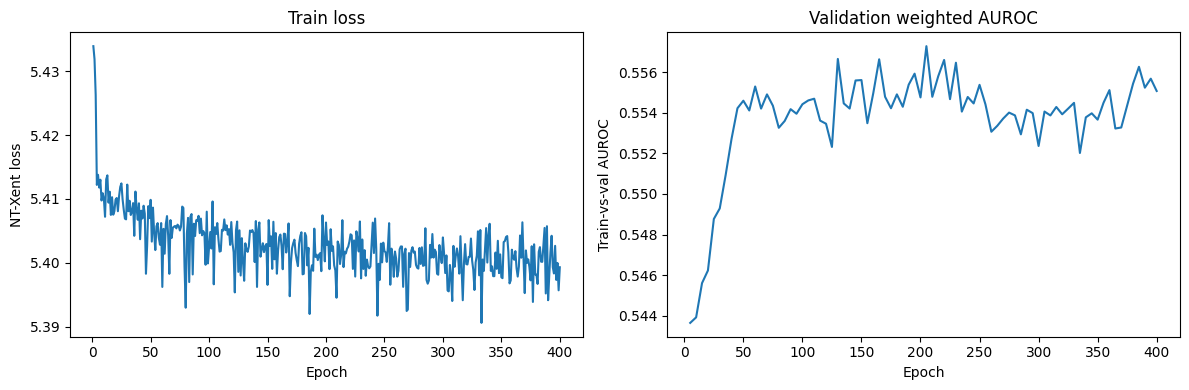

Saved /content/drive/MyDrive/6.8711_Project/checkpoints/antiberty_run1/training_curves.png


In [17]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path(OUTPUT_DIR) / "metrics.json"
metrics = json.loads(metrics_path.read_text())

train_epochs = [m["epoch"] for m in metrics]
train_loss = [m["train_loss"] for m in metrics]
val_rows = [m for m in metrics if "train_vs_val" in m]
val_epochs = [m["epoch"] for m in val_rows]
val_auroc = [m["train_vs_val"]["weighted_auroc"] for m in val_rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_epochs, train_loss)
ax1.set(title="Train loss", xlabel="Epoch", ylabel="NT-Xent loss")
ax2.plot(val_epochs, val_auroc)
ax2.set(title="Validation weighted AUROC", xlabel="Epoch", ylabel="Train-vs-val AUROC")
plt.tight_layout()
fig_path = Path(OUTPUT_DIR) / "training_curves.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)